# Expected Free energy minimization for mobile robot navigation

### Joost Leliveld, last update: 06-02-2026  
Heavily inspired from Wouter Kouw

### Usecase:

A robot that moves according to the constant-velocity model is observed by an external static camera. The camera provides image measurements (pixel location) to help the robot navigate from point A to point B. The ground is assumed to be planar and the camera intrinsics as well as the homography known. This makes the observation model nonlinear and the effects of this will be studied for different control types. 

### Dynamics (linear constant-velocity model)

Consider a robot that moves according to the constant-velocity model:

$$\underbrace{\begin{bmatrix} x_{1,k} \\ x_{2,k} \\ \dot{x}_{1,k} \\ \dot{x}_{2,k} \end{bmatrix}}_{z_k}
=
\underbrace{\begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}}_{A}
\underbrace{\begin{bmatrix} x_{1,k-1} \\ x_{2,k-1} \\ \dot{x}_{1,k-1} \\ \dot{x}_{2,k-1} \end{bmatrix}}_{z_{k-1}}
+
\underbrace{\begin{bmatrix}
0 & 0 \\
0 & 0 \\
\Delta t & 0 \\
0 & \Delta t
\end{bmatrix}}_{B}
\underbrace{\begin{bmatrix} u_{1,k} \\ u_{2,k} \end{bmatrix}}_{u_k}
+ q_k\, .$$


Process noise is white, $q_k \sim \mathcal{N}(0,Q)$, with

$$Q =
\begin{bmatrix}
\frac{\Delta t^3}{3}\rho_1 & 0 & \frac{\Delta t^2}{2}\rho_1 & 0 \\
0 & \frac{\Delta t^3}{3}\rho_2 & 0 & \frac{\Delta t^2}{2}\rho_2 \\
\frac{\Delta t^2}{2}\rho_1 & 0 & \Delta t\rho_1 & 0 \\
0 & \frac{\Delta t^2}{2}\rho_2 & 0 & \Delta t\rho_2
\end{bmatrix}\, .$$


### Observations: external oblique camera (pixels)

A static external camera observes the robot in the image plane. The measurement is the pixel location:

$$o_k \triangleq \begin{bmatrix} u_k^{\mathrm{pix}} \\ v_k^{\mathrm{pix}} \end{bmatrix} \in \mathbb{R}^2.$$

The camera measurement is generated by a nonlinear projective mapping:

$$o_k = g(z_k) + r_k,\qquad r_k \sim \mathcal{N}(0,R),$$

where $g(z_k)$ is defined as the composition of (i) ground-plane embedding into 3D, (ii) rigid transform into the camera frame, and (iii) perspective projection to pixels. Since the camera observes position on the ground plane, the observation model depends only on the position components. 

#### Projective mapping (state $\rightarrow$ pixels)
https://docs.opencv.org/4.x/d9/dab/tutorial_homography.html 
1) **Embed the ground-plane point into 3D (world frame).**  
Assuming a planar ground ($Z=0$):

$$P_w(p_k) \triangleq \begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix}
=
\begin{bmatrix} x_{1,k} \\ x_{2,k} \\ 0 \\ 1 \end{bmatrix}.$$

2) **Transform world coordinates to camera coordinates.**  
Let $(R_{cw},t_{cw})$ be the camera extrinsics (world-to-camera):

$$\begin{bmatrix} X_c \\ Y_c \\ Z_c \end{bmatrix}
=
R_{cw}\begin{bmatrix} X \\ Y \\ Z \end{bmatrix} + t_{cw}.$$

3) **Perspective division (nonlinearity).**  
Normalized image coordinates are obtained by:

$$x_n = \frac{X_c}{Z_c},\qquad y_n = \frac{Y_c}{Z_c}.$$

4) **Intrinsics map normalized coordinates to pixels.**  
With camera intrinsics $(f_x,f_y,c_x,c_y)$:

$$u_k^{\mathrm{pix}} = f_x x_n + c_x,\qquad
v_k^{\mathrm{pix}} = f_y y_n + c_y.$$

Putting these steps together defines $g(z_k)$:

$$g(z_k) \triangleq 
\begin{bmatrix}
f_x \frac{X_c(p_k)}{Z_c(p_k)} + c_x \\
f_y \frac{Y_c(p_k)}{Z_c(p_k)} + c_y
\end{bmatrix},
\qquad p_k = C z_k.$$

The mapping is nonlinear because of the perspective division by $Z_c(p_k)$, which induces state-dependent sensitivity of pixels to changes in ground-plane position.


### Probabilistic model

We use a probabilistic state-space model with linear-Gaussian dynamics and a nonlinear camera observation model:

$$\begin{align}
p(z_0) &= \mathcal{N}(z_0 \mid m_0, S_0) \\
p(z_k \mid z_{k-1}, u_k) &= \mathcal{N}(z_k \mid A z_{k-1} + B u_k, Q) \\
p(o_k \mid z_k) &= \mathcal{N}(o_k \mid g(z_k), R)\, .
\end{align}$$

Here, $z_k \in \mathbb{R}^4$ is the ground-plane constant-velocity state and $o_k$ is the external camera measurement in the image plane. 


### Gaussian approximation to likelihood

Because $g(\cdot)$ is nonlinear, the likelihood $p(o_k \mid z_k)$ is generally non-Gaussian as a function of $z_k$:

Using the projective observation model,

$$
g(z_k)
=
\begin{bmatrix}
f_x \dfrac{X_c(p_k)}{Z_c(p_k)} + c_x \\
f_y \dfrac{Y_c(p_k)}{Z_c(p_k)} + c_y
\end{bmatrix},
$$

the likelihood can be written (up to a normalization constant) as

$$
p(o_k \mid z_k)
=
\frac{1}{\sqrt{(2\pi)^2 \det R}}
\exp\!\Big(-\tfrac12 (o_k-g(z_k))^\top R^{-1}(o_k-g(z_k))\Big).
$$


$$
\log p(o_k \mid z_k)
=
-\tfrac12 \big(o_k - g(z_k)\big)^\top R^{-1} \big(o_k - g(z_k)\big).
$$

Since the term is not just a power of o or z the likelihood is non-Gaussian, however we approximate the joint $(z_k, o_k)$ as a Gaussian:

$$p(o_k, z_k) \approx \mathcal{N}\!\left(
\begin{bmatrix} z_k \\ o_k \end{bmatrix}
\Bigg|\,
\begin{bmatrix} m_k \\ \mu_k \end{bmatrix},
\begin{bmatrix} S_k & \Gamma_k \\ \Gamma_k^{\top} & \Sigma_k \end{bmatrix}
\right)\, .$$

Here:
- $m_k, S_k$ are the predicted state mean and covariance,
- $\mu_k, \Sigma_k$ are the predicted observation mean and covariance,
- $\Gamma_k$ is the state--observation cross-covariance.

Because this joint is Gaussian, conditioning yields an approximate Gaussian likelihood:

$$\begin{align}
p(o_k \mid z_k)
&\approx \mathcal{N}\!\left(
o_k \,\Big|\,
\mu_k + \Gamma_k^{\top} S_k^{-1}(z_k - m_k),
\ \Sigma_k - \Gamma_k^{\top} S_k^{-1}\Gamma_k
\right)\, .
\end{align}$$

The parameters $(\mu_k, \Sigma_k, \Gamma_k)$ are obtained by a Gaussian approximation method:
first-order Taylor (ET1/EFE1), second-order Taylor (ET2/EFE2), or sigma-point (UT) approximation.


## Posterior predictive

The posterior predictive distribution of the observation is obtained by marginalizing
over the latent state:

$$
\begin{align}
p(o_k \mid o_{1:k-1})
&= \int p(o_k \mid z_k)\, p(z_k \mid o_{1:k-1}) \, dz_k \tag{1}\\
&= \int \mathcal N\!\left(
\begin{bmatrix} z_k \\ o_k \end{bmatrix}
\Bigg|\,
\begin{bmatrix} m_k \\ \mu_k \end{bmatrix},
\begin{bmatrix}
S_k & \Gamma_k \\
\Gamma_k^\top & \Sigma_k
\end{bmatrix}
\right) dz_k \tag{2}\\
&= \mathcal N(o_k \mid \mu_k, \Sigma_k). \tag{3}
\end{align}
$$

That is, marginalizing a joint Gaussian yields a Gaussian predictive distribution
with mean $\mu_k$ and covariance $\Sigma_k$.


## Planning and control

### Expected Free Energy (EFE) objective

The Expected Free Energy objective for a single time step is given by

$$
\mathcal J_k(u_t)
=
\mathcal C
+
\frac{1}{2}\,\mathrm{tr}\!\left(S_*^{-1}(\Sigma_t + \Sigma_\star)\right)
+
\frac{1}{2}\,\ln
\frac{\left| \Sigma_t - \Gamma_t^\top S_t^{-1} \Gamma_t \right|}
{\left| \Sigma_t \right|}. \tag{1}
$$

The first term encodes the expected risk, while the log-determinant term captures
expected ambiguity through the conditional observation covariance.

### Horizon-based control optimization

For a planning horizon of $T$ steps, the optimal control sequence is obtained as

$$
\begin{align}
\hat u
&= \arg\max_{u \in \mathcal U} q^\star(u) \tag{1}\\
&= \arg\min_{u \in \mathcal U}
\sum_{t=1}^{T} \mathcal J_t(u_t)
- \ln p(u_t). \tag{2}
\end{align}
$$


In [41]:
from pathlib import Path
import sys

CWD = Path.cwd()
ROOT = CWD if (CWD / "scripts").exists() else CWD.parent
sys.path.insert(0, str(ROOT / "scripts"))
ANIM_DIR = ROOT / "scripts" / "animations"
ANIM_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = ROOT / "scripts" / "figures"

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.optimize import minimize
from scipy.stats import multivariate_normal
from tqdm import tqdm

from robots import FieldBot, update
from botnav_efe_helpers import PlanarCamera, EFEAgent, predict, correct, EFE, evidence, planned_trajectory
from botnav_efe_jax import bind_agent_jax, make_homography_g_jax, make_valgrad_fn


In [42]:
# Matplotlib settings
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['lines.markersize'] = 3

def plot_cov_ellipse(ax, mean, cov, n_std=1, color='blue', alpha=0.3, linewidth=0):
    eigenvals, eigenvecs = np.linalg.eigh(cov)
    order = eigenvals.argsort()[::-1]
    eigenvals, eigenvecs = eigenvals[order], eigenvecs[:, order]

    angle = np.degrees(np.arctan2(*eigenvecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvals)

    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  color=color, alpha=alpha, linewidth=linewidth)
    ax.add_patch(ell)


In [ ]:
# =========================
# EXPERIMENT SETUP (point-mass, Julia-like)
# =========================

# --- Time ---
Δt = 0.2
len_trial = 40
tsteps = np.arange(0, len_trial * Δt, Δt)
len_horizon = 5

# --- Camera (from camera-projection-investigation.ipynb) ---
camera = PlanarCamera(
    cam_pos=np.array([0.0, 0.0, 3.0]),
    look_at=np.array([0.0, -3.0, 0.0]),
    img_width=640,
    img_height=480,
    fov_h_rad=np.deg2rad(90.0),
    up_hint=(0.0, 0.0, 1.0),
)

def g(x):
    return camera.g(x)

# --- Dynamics / control ---
ρ = np.array([1e-2, 1e-2])
η = 0.0
u_lims = (-1.0, 1.0)

# --- Start / goal (straight line in front of camera) ---
y_line = -2.0
x_start, x_goal = -1.0, 1.0
start_xy = np.array([x_start, y_line])
goal_xy = np.array([x_goal, y_line])

z_0 = np.array([start_xy[0], start_xy[1], 0.0, 0.0])
z_star = np.array([goal_xy[0], goal_xy[1], 0.0, 0.0])

start_obs = g(z_0)
goal_obs = g(z_star)

def in_frame(obs):
    u, v = obs
    return (
        np.isfinite(u)
        and np.isfinite(v)
        and 0.0 <= u < camera.img_width
        and 0.0 <= v < camera.img_height
    )

assert in_frame(start_obs), f"Start not in frame: {start_obs}"
assert in_frame(goal_obs), f"Goal not in frame: {goal_obs}"

sigma_obs = 2.0          # px
goal_sigma_pix = 5.0    # px

R = np.diag([sigma_obs**2, sigma_obs**2])
goal = (goal_obs, np.diag([goal_sigma_pix**2, goal_sigma_pix**2]))


# --- Initial belief ---
m_0 = z_0.copy()
S_0 = 0.5 * np.eye(4)

# --- Robot + Agent ---
fbot = FieldBot(g, ρ, σ=sigma_obs, Δt=Δt, control_lims=u_lims)
fbot.R = R.copy()

agent = EFEAgent(goal, g, ρ, sigma=sigma_obs, eta=η, dt=Δt, time_horizon=len_horizon)
agent.R = R.copy()

print("Start:", start_xy, "uv=", start_obs)
print("Goal :", goal_xy, "uv=", goal_obs)
print("obs_span:", round(obs_span, 3), "sigma_obs:", round(sigma_obs, 3), "goal_sigma:", round(goal_sigma, 3))


Start: [-1. -2.] uv= [410.50966799 304.        ]
Goal : [ 1. -2.] uv= [229.49033201 304.        ]
obs_span: 181.019 sigma_obs: 0.181 goal_sigma: 128.0


In [44]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

params_j = bind_agent_jax(agent)
g_jax = make_homography_g_jax(camera.H)

assert agent.time_horizon == len_horizon
assert params_j.time_horizon == len_horizon


In [45]:
def animate_run(z_sim, z_est, z_pln, label, filename, xl, yl):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(xl)
    ax.set_ylim(yl)
    ax.set_aspect('equal')
    ax.set_xlabel("position x")
    ax.set_ylabel("position y")

    def animate_frame(k):
        ax.clear()
        ax.set_xlim(xl)
        ax.set_ylim(yl)
        ax.set_aspect('equal')
        ax.set_title(f"{label}: {k+1}/{len_trial}")
        ax.set_xlabel("position x")
        ax.set_ylabel("position y")

        ax.scatter([z_0[0]], [z_0[1]], color="blue", label="start", s=25)
        ax.scatter([z_star[0]], [z_star[1]], color="red", label="goal state", s=25)

        ax.plot(z_sim[0, 1:k+1], z_sim[1, 1:k+1], c="blue", label="true", alpha=0.5)
        ax.plot(z_est[0][0, 1:k+1], z_est[0][1, 1:k+1], c="purple", label="inferred", alpha=0.5)
        plot_cov_ellipse(ax, z_est[0][0:2, k], z_est[1][0:2, 0:2, k],
                         n_std=1, color="purple", alpha=0.3, linewidth=0)

        ax.plot(z_pln[0][k, 0, :], z_pln[0][k, 1, :], c="orange", label="planned")
        for j in range(len_horizon):
            plot_cov_ellipse(ax, z_pln[0][k, 0:2, j], z_pln[1][k, 0:2, 0:2, j],
                             n_std=1, color="orange", alpha=0.3, linewidth=0)

        if k == 2:
            ax.legend(loc='upper left')

    anim = FuncAnimation(fig, animate_frame, frames=range(2, len_trial), interval=1000, repeat=False)
    anim.save(str(ANIM_DIR / filename), writer=PillowWriter(fps=1))
    plt.close()


In [46]:
def plot_run(z_sim, z_est, label, xl=None, yl=None, save_path=None):
    # Camera footprint in world coordinates
    W, H = camera.img_width, camera.img_height
    corner_pixels = [(0, 0), (W, 0), (W, H), (0, H), (0, 0)]
    corner_world = []
    for u, v in corner_pixels:
        x, y = camera.pixel_to_world(u, v)
        if np.isfinite(x) and np.isfinite(y):
            corner_world.append([x, y])
    corner_world = np.array(corner_world)

    fig, ax = plt.subplots(figsize=(8, 5))

    # Auto-limits include trajectories, goal, and footprint
    if xl is None or yl is None:
        xs = [z_sim[0, :], z_est[0][0, :], np.array([z_star[0]])]
        ys = [z_sim[1, :], z_est[0][1, :], np.array([z_star[1]])]
        if corner_world.size > 0:
            xs.append(corner_world[:, 0])
            ys.append(corner_world[:, 1])
        xs = np.concatenate(xs)
        ys = np.concatenate(ys)
        margin = 0.2
        xl = [xs.min() - margin, xs.max() + margin]
        yl = [ys.min() - margin, ys.max() + margin]

    ax.set_xlim(xl)
    ax.set_ylim(yl)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)

    if corner_world.size > 0:
        ax.plot(corner_world[:, 0], corner_world[:, 1], ls='--', lw=1.2,
                color='orange', alpha=0.55, label='camera footprint')

    ax.scatter([z_sim[0, 0]], [z_sim[1, 0]], color='green', marker='D', label='start', s=64)
    ax.scatter([z_star[0]], [z_star[1]], color='red', label='goal', s=64)

    ax.plot(z_sim[0, :], z_sim[1, :], c='blue', label='true')
    ax.plot(z_est[0][0, :], z_est[0][1, :], c='purple', label='inferred')

    for j in range(len_trial):
        plot_cov_ellipse(ax, z_est[0][0:2, j], z_est[1][0:2, 0:2, j],
                         n_std=1, color='purple', alpha=0.1, linewidth=0)

    ax.set_title(label)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1.02, 0.5))

    fig.tight_layout(rect=[0, 0, 0.82, 1])
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()


## Model: EFE(ET2)

In [47]:
# assumes params_j and g_jax already defined in the JAX setup cell
valgrad = make_valgrad_fn(params_j, g_jax, approx="ET2", add_ambiguity=True, mode="fwd")

z_est = (np.zeros((4, len_trial)), np.zeros((4, 4, len_trial)))
z_pln = (np.zeros((len_trial, 4, len_horizon)), np.zeros((len_trial, 4, 4, len_horizon)))
y_pln = (np.zeros((len_trial, agent.Dy, len_horizon)), np.zeros((len_trial, agent.Dy, agent.Dy, len_horizon)))
z_sim = np.zeros((4, len_trial))
y_sim = np.zeros((agent.Dy, len_trial))
u_sim = np.zeros((2, len_trial))
F_EFE2 = np.zeros(len_trial)
J_EFE2 = np.zeros(len_trial)

z_est[0][:, 0] = m_0
z_est[1][:, :, 0] = S_0

# Initial state
z_sim[:, 0] = z_0

# Start recursion
m_kmin1 = m_0
S_kmin1 = S_0

policy = np.zeros((2, len_horizon))

for k in tqdm(range(1, len_trial), desc="EFE2 Experiment"):

    # Interact with environment
    y_sim[:, k], z_sim[:, k] = update(fbot, z_sim[:, k-1], u_sim[:, k-1])

    # State estimation
    m_k_pred, S_k_pred = predict(agent, m_kmin1, S_kmin1, u_sim[:, k-1])
    m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET2")

    # Compute model evidence
    F_EFE2[k] = evidence(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET2")
    J_EFE2[k] = -multivariate_normal.logpdf(y_sim[:, k], goal[0], goal[1])

    # Store state estimates
    z_est[0][:, k] = m_k
    z_est[1][:, :, k] = S_k

    # Planning
    bounds = [(u_lims[0], u_lims[1]) for _ in range(2 * len_horizon)]

    def f(u):
        val, _ = valgrad(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.array(val)

    def grad_u(u):
        _, grad = valgrad(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.array(grad)

    x0 = np.zeros(2 * len_horizon) if k == 1 else np.concatenate([policy[:, 1:].T.reshape(-1), policy[:, -1]])

    result = minimize(
        f,
        x0,
        jac=grad_u,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 200, 'maxfun': 2000, 'ftol': 1e-6}
    )

    # Extract minimizing control
    policy = result.x.reshape((len_horizon, 2)).T
    if k == 1:
        assert policy.shape == (2, len_horizon)
    u_sim[:, k] = policy[:, 0]

    # Planning
    planned_states, planned_obs = planned_trajectory(agent, policy, (m_k, S_k), approx="ET2")
    z_pln[0][k, :, :] = planned_states[0]
    z_pln[1][k, :, :, :] = planned_states[1]
    y_pln[0][k, :, :] = planned_obs[0]
    y_pln[1][k, :, :, :] = planned_obs[1]

    # Update recursion
    m_kmin1 = m_k
    S_kmin1 = S_k


EFE2 Experiment: 100%|██████████| 39/39 [00:04<00:00,  9.06it/s]


In [48]:
# --- Camera footprint (robust) ---
W, H = camera.img_width, camera.img_height
corner_pixels = [(0, 0), (W, 0), (W, H), (0, H)]
corner_world = []

for u, v in corner_pixels:
    x, y = camera.pixel_to_world(u, v)
    if np.isfinite(x) and np.isfinite(y):
        corner_world.append([x, y])

corner_world = np.array(corner_world)

if corner_world.shape[0] == 4:
    # sort corners around centroid to avoid crossing
    c = corner_world.mean(axis=0)
    ang = np.arctan2(corner_world[:, 1] - c[1], corner_world[:, 0] - c[0])
    corner_world = corner_world[np.argsort(ang)]
    corner_world = np.vstack([corner_world, corner_world[0]])  # close polygon
else:
    print("Footprint is not a closed quad (missing corner).")


In [49]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]

animate_run(
    z_sim=z_sim,
    z_est=z_est,
    z_pln=z_pln,
    label="EFE2",
    filename="bev2image-experiment-EFE2-path.gif",
    xl=xl,
    yl=yl,
)


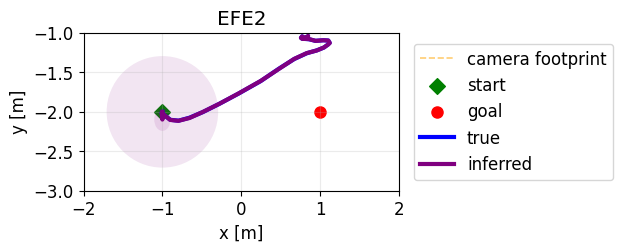

In [50]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]
plot_run(z_sim, z_est, label="EFE2", xl=xl, yl=yl, save_path=FIG_DIR / "bev2image-experiment-EFE2-zoom.png")



In [51]:
# JAX val+grad for EFE1 (forward-mode)
valgrad_efe1 = make_valgrad_fn(params_j, g_jax, approx="ET1", add_ambiguity=True, mode="fwd")

# Preallocate
z_est = (np.zeros((4, len_trial)), np.zeros((4, 4, len_trial)))
z_pln = (np.zeros((len_trial, 4, len_horizon)), np.zeros((len_trial, 4, 4, len_horizon)))
y_pln = (np.zeros((len_trial, agent.Dy, len_horizon)), np.zeros((len_trial, agent.Dy, agent.Dy, len_horizon)))
z_sim = np.zeros((4, len_trial))
y_sim = np.zeros((agent.Dy, len_trial))
u_sim = np.zeros((2, len_trial))
F_EFE1 = np.zeros(len_trial)
J_EFE1 = np.zeros(len_trial)
z_est[0][:, 0] = m_0
z_est[1][:, :, 0] = S_0
# Initial state
z_sim[:, 0] = z_0

# Start recursion
m_kmin1 = m_0
S_kmin1 = S_0

policy = np.zeros((2, len_horizon))

for k in tqdm(range(1, len_trial), desc="EFE1 Experiment"):

    # Interact with environment
    y_sim[:, k], z_sim[:, k] = update(fbot, z_sim[:, k-1], u_sim[:, k-1])

    # State estimation
    m_k_pred, S_k_pred = predict(agent, m_kmin1, S_kmin1, u_sim[:, k-1])
    m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET1")

    # Compute model evidence
    F_EFE1[k] = evidence(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET1")
    J_EFE1[k] = -multivariate_normal.logpdf(y_sim[:, k], goal[0], goal[1])

    # Store state estimates
    z_est[0][:, k] = m_k
    z_est[1][:, :, k] = S_k

    # Planning
    bounds = [(u_lims[0], u_lims[1]) for _ in range(2 * len_horizon)]

    def f(u):
        val, _ = valgrad_efe1(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.array(val)

    def grad_u(u):
        _, grad = valgrad_efe1(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.array(grad)

    x0 = np.zeros(2 * len_horizon) if k == 1 else np.concatenate([policy[:, 1:].T.reshape(-1), policy[:, -1]])

    result = minimize(
        f,
        x0,
        jac=grad_u,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 200, 'maxfun': 2000, 'ftol': 1e-6}
    )

    # Extract minimizing control
    policy = result.x.reshape((len_horizon, 2)).T
    if k == 1:
        assert policy.shape == (2, len_horizon)
    u_sim[:, k] = policy[:, 0]

    # Planning
    planned_states, planned_obs = planned_trajectory(agent, policy, (m_k, S_k), approx="ET1")
    z_pln[0][k, :, :] = planned_states[0]
    z_pln[1][k, :, :, :] = planned_states[1]
    y_pln[0][k, :, :] = planned_obs[0]
    y_pln[1][k, :, :, :] = planned_obs[1]

    # Update recursion
    m_kmin1 = m_k
    S_kmin1 = S_k


EFE1 Experiment: 100%|██████████| 39/39 [00:02<00:00, 17.29it/s]


In [52]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]

animate_run(
    z_sim=z_sim,
    z_est=z_est,
    z_pln=z_pln,
    label="EFE1",
    filename="bev2image-experiment-EFE1-path.gif",
    xl=xl,
    yl=yl,
)


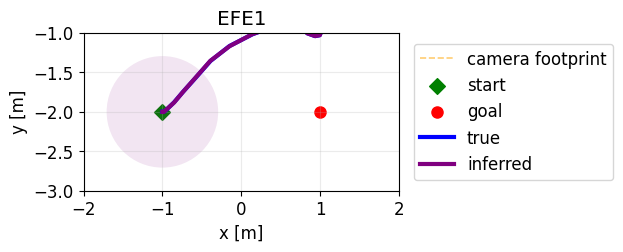

In [53]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]
plot_run(z_sim, z_est, label="EFE1", xl=xl, yl=yl, save_path=FIG_DIR / "bev2image-experiment-EFE1-zoom.png")



In [54]:
# JAX val+grad for EFER (ET2, no ambiguity)
valgrad_efer = make_valgrad_fn(params_j, g_jax, approx="ET2", add_ambiguity=False, mode="fwd")

# Preallocate
z_est = (np.zeros((4, len_trial)), np.zeros((4, 4, len_trial)))
z_pln = (np.zeros((len_trial, 4, len_horizon)), np.zeros((len_trial, 4, 4, len_horizon)))
y_pln = (np.zeros((len_trial, agent.Dy, len_horizon)), np.zeros((len_trial, agent.Dy, agent.Dy, len_horizon)))
z_sim = np.zeros((4, len_trial))
y_sim = np.zeros((agent.Dy, len_trial))
u_sim = np.zeros((2, len_trial))
F_EFER = np.zeros(len_trial)
J_EFER = np.zeros(len_trial)

# Initialize first estimate (avoids line to origin)
z_est[0][:, 0] = m_0
z_est[1][:, :, 0] = S_0

# Initial state
z_sim[:, 0] = z_0

# Start recursion
m_kmin1 = m_0
S_kmin1 = S_0

policy = np.zeros((2, len_horizon))

for k in tqdm(range(1, len_trial), desc="EFER Experiment"):

    # Interact with environment
    y_sim[:, k], z_sim[:, k] = update(fbot, z_sim[:, k-1], u_sim[:, k-1])

    # State estimation
    m_k_pred, S_k_pred = predict(agent, m_kmin1, S_kmin1, u_sim[:, k-1])
    m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET2")

    # Compute model evidence (Julia uses corrected + ET2)
    F_EFER[k] = evidence(agent, y_sim[:, k], m_k, S_k, approx="ET2")
    J_EFER[k] = -multivariate_normal.logpdf(y_sim[:, k], goal[0], goal[1])

    # Store state estimates
    z_est[0][:, k] = m_k
    z_est[1][:, :, k] = S_k

    # Planning
    bounds = [(u_lims[0], u_lims[1]) for _ in range(2 * len_horizon)]

    def f(u):
        val, _ = valgrad_efer(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.array(val)

    def grad_u(u):
        _, grad = valgrad_efer(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.array(grad)

    x0 = np.zeros(2 * len_horizon) if k == 1 else np.concatenate([policy[:, 1:].T.reshape(-1), policy[:, -1]])

    result = minimize(
        f,
        x0,
        jac=grad_u,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 200, 'maxfun': 2000, 'ftol': 1e-6}
    )

    # Extract minimizing control
    policy = result.x.reshape((len_horizon, 2)).T
    if k == 1:
        assert policy.shape == (2, len_horizon)
    u_sim[:, k] = policy[:, 0]

    # Planning
    planned_states, planned_obs = planned_trajectory(agent, policy, (m_k, S_k), approx="ET2")
    z_pln[0][k, :, :] = planned_states[0]
    z_pln[1][k, :, :, :] = planned_states[1]
    y_pln[0][k, :, :] = planned_obs[0]
    y_pln[1][k, :, :, :] = planned_obs[1]

    # Update recursion
    m_kmin1 = m_k
    S_kmin1 = S_k


EFER Experiment: 100%|██████████| 39/39 [00:03<00:00, 11.25it/s]


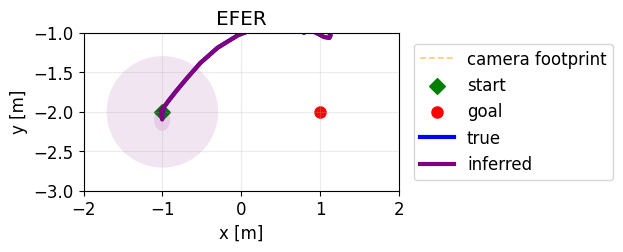

In [55]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]
plot_run(z_sim, z_est, label="EFER", xl=xl, yl=yl, save_path=FIG_DIR / "bev2image-experiment-EFER-zoom.png")


In [56]:
tF_EFE2 = np.sum(F_EFE2)
tF_EFE1 = np.sum(F_EFE1)
tF_EFER = np.sum(F_EFER)

print(f"F EFE2 = {tF_EFE2}")
print(f"F EFE1 = {tF_EFE1}")
print(f"F EFER = {tF_EFER}")


F EFE2 = 111.2911210001588
F EFE1 = 124.04955322804268
F EFER = -24.202803959649746


In [57]:
tJ_EFE2 = np.sum(J_EFE2)
tJ_EFE1 = np.sum(J_EFE1)
tJ_EFER = np.sum(J_EFER)

print(f"Total goal prior -log-likelihood EFE2 = {tJ_EFE2}")
print(f"Total goal prior -log-likelihood EFE1 = {tJ_EFE1}")
print(f"Total goal prior -log-likelihood EFER = {tJ_EFER}")


Total goal prior -log-likelihood EFE2 = 463.3562580171948
Total goal prior -log-likelihood EFE1 = 466.723832776114
Total goal prior -log-likelihood EFER = 467.5872480761389


In [58]:
perf_EFE2 = np.sum(F_EFE2) + np.sum(J_EFE2)
perf_EFE1 = np.sum(F_EFE1) + np.sum(J_EFE1)
perf_EFER = np.sum(F_EFER) + np.sum(J_EFER)

print(f"Performance EFE2 = {perf_EFE2}")
print(f"Performance EFE1 = {perf_EFE1}")
print(f"Performance EFER = {perf_EFER}")


Performance EFE2 = 574.6473790173536
Performance EFE1 = 590.7733860041567
Performance EFER = 443.38444411648914


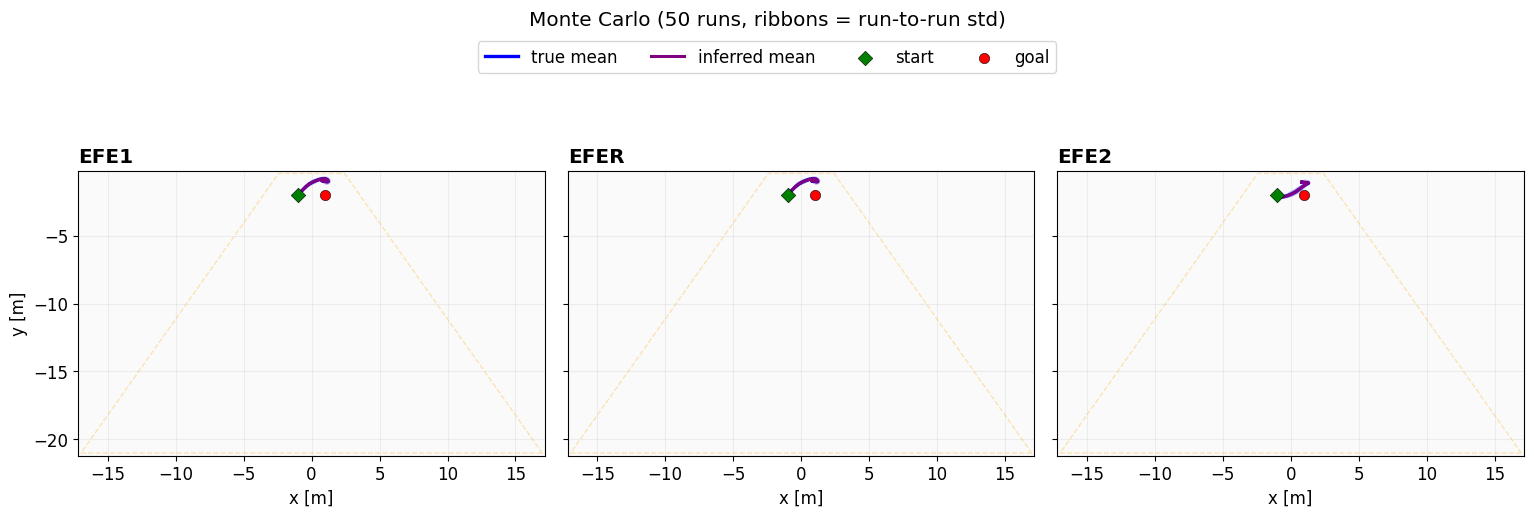

In [59]:
# --- Monte Carlo run + mean/std plots (EFE1, EFER, EFE2) ---

n_runs = 50
seed0 = 0
use_sem = False

def run_mc(approx, add_ambiguity, n_runs=50, seed0=0, maxiter=200, maxfun=2000, ftol=1e-6, grad_mode="fwd", use_sem=False):
    true_runs = np.zeros((n_runs, len_trial, 2))
    est_runs = np.zeros((n_runs, len_trial, 2))
    u_runs = np.zeros((n_runs, len_trial, 2))

    valgrad = make_valgrad_fn(params_j, g_jax, approx=approx, add_ambiguity=add_ambiguity, mode=grad_mode)
    bounds = [u_lims for _ in range(2 * len_horizon)]

    for r in range(n_runs):
        np.random.seed(seed0 + r)

        z_sim = np.zeros((4, len_trial))
        y_sim = np.zeros((agent.Dy, len_trial))
        u_sim = np.zeros((2, len_trial))
        z_est = (np.zeros((4, len_trial)), np.zeros((4, 4, len_trial)))

        z_sim[:, 0] = z_0
        z_est[0][:, 0] = m_0
        z_est[1][:, :, 0] = S_0

        m_kmin1 = m_0
        S_kmin1 = S_0
        policy = np.zeros((2, len_horizon))

        for k in range(1, len_trial):
            y_sim[:, k], z_sim[:, k] = update(fbot, z_sim[:, k - 1], u_sim[:, k - 1])

            m_k_pred, S_k_pred = predict(agent, m_kmin1, S_kmin1, u_sim[:, k - 1])
            m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx=approx)

            z_est[0][:, k] = m_k
            z_est[1][:, :, k] = S_k

            def f(u):
                val, _ = valgrad(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
                return float(val)

            def grad_u(u):
                _, grad = valgrad(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
                return np.asarray(grad, dtype=float)

            x0 = np.zeros(2 * len_horizon) if k == 1 else np.concatenate([policy[:, 1:].T.reshape(-1), policy[:, -1]])
            result = minimize(
                f,
                x0,
                jac=grad_u,
                method='L-BFGS-B',
                bounds=bounds,
                options={'maxiter': maxiter, 'maxfun': maxfun, 'ftol': ftol},
            )

            policy = result.x.reshape((len_horizon, 2)).T
            if k == 1:
                assert policy.shape == (2, len_horizon)

            u_sim[:, k] = policy[:, 0]

            m_kmin1 = m_k
            S_kmin1 = S_k

        true_runs[r] = z_sim[:2].T
        est_runs[r] = z_est[0][:2].T
        u_runs[r] = u_sim.T

    return true_runs, est_runs, u_runs


def plot_ribbon(ax, x_mean, y_mean, x_spread, y_spread, color, alpha=0.2):
    dx = np.gradient(x_mean)
    dy = np.gradient(y_mean)
    norm = np.sqrt(dx ** 2 + dy ** 2) + 1e-9
    nx = -dy / norm
    ny = dx / norm
    r = np.sqrt(x_spread ** 2 + y_spread ** 2)

    x_upper = x_mean + nx * r
    y_upper = y_mean + ny * r
    x_lower = x_mean - nx * r
    y_lower = y_mean - ny * r

    ax.fill(
        np.concatenate([x_upper, x_lower[::-1]]),
        np.concatenate([y_upper, y_lower[::-1]]),
        color=color,
        alpha=alpha,
        linewidth=0,
        zorder=1,
    )


def camera_footprint_world(camera):
    W, H = camera.img_width, camera.img_height
    corner_pixels = [(0, 0), (W, 0), (W, H), (0, H), (0, 0)]
    pts = []
    for u, v in corner_pixels:
        x, y = camera.pixel_to_world(u, v)
        if np.isfinite(x) and np.isfinite(y):
            pts.append([x, y])
    return np.array(pts)


methods = [
    ("EFE1", "ET1", True),
    ("EFER", "ET2", False),
    ("EFE2", "ET2", True),
]

mc_results = {}
for title, approx, add_amb in methods:
    true_runs, est_runs, u_runs = run_mc(
        approx,
        add_amb,
        n_runs=n_runs,
        seed0=seed0,
        maxiter=200,
        maxfun=2000,
        ftol=1e-6,
        grad_mode="fwd",
        use_sem=use_sem,
    )
    mc_results[title] = {"true_runs": true_runs, "est_runs": est_runs, "u_runs": u_runs}

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), sharex=True, sharey=True)

all_x = [start_xy[0], goal_xy[0]]
all_y = [start_xy[1], goal_xy[1]]

footprint = camera_footprint_world(camera)
if footprint.size > 0:
    all_x.extend(footprint[:, 0].tolist())
    all_y.extend(footprint[:, 1].tolist())

spread_label = "SEM" if use_sem else "run-to-run std"

for i, (ax, (title, _, _)) in enumerate(zip(axes, methods)):
    true_runs = mc_results[title]["true_runs"]
    est_runs = mc_results[title]["est_runs"]

    true_mean = true_runs.mean(axis=0)
    true_spread = true_runs.std(axis=0, ddof=1)
    est_mean = est_runs.mean(axis=0)
    est_spread = est_runs.std(axis=0, ddof=1)

    if use_sem:
        true_spread = true_spread / np.sqrt(n_runs)
        est_spread = est_spread / np.sqrt(n_runs)

    all_x.extend(true_mean[:, 0].tolist())
    all_x.extend(est_mean[:, 0].tolist())
    all_y.extend(true_mean[:, 1].tolist())
    all_y.extend(est_mean[:, 1].tolist())

    ax.set_facecolor("#fafafa")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    if i == 0:
        ax.set_ylabel("y [m]")
    ax.grid(alpha=0.18, linewidth=0.8)

    if footprint.size > 0:
        ax.plot(footprint[:, 0], footprint[:, 1], ls='--', lw=1.0,
                color='orange', alpha=0.28, zorder=0)

    plot_ribbon(
        ax,
        true_mean[:, 0],
        true_mean[:, 1],
        true_spread[:, 0],
        true_spread[:, 1],
        color="blue",
        alpha=0.22,
    )
    plot_ribbon(
        ax,
        est_mean[:, 0],
        est_mean[:, 1],
        est_spread[:, 0],
        est_spread[:, 1],
        color="purple",
        alpha=0.16,
    )

    ax.plot(true_mean[:, 0], true_mean[:, 1], color="blue", lw=2.4, label="true mean", zorder=3)
    ax.plot(est_mean[:, 0], est_mean[:, 1], color="purple", lw=2.2, label="inferred mean", zorder=3)

    ax.scatter([z_0[0]], [z_0[1]], color="green", marker="D", s=55,
               edgecolors="black", linewidths=0.4, label="start", zorder=5)
    ax.scatter([z_star[0]], [z_star[1]], color="red", s=55,
               edgecolors="black", linewidths=0.4, label="goal", zorder=5)

x_margin = 0.2
y_margin = 0.2
xl = [min(all_x) - x_margin, max(all_x) + x_margin]
yl = [min(all_y) - y_margin, max(all_y) + y_margin]
for ax in axes:
    ax.set_xlim(xl)
    ax.set_ylim(yl)

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=True,
)

fig.suptitle(f"Monte Carlo ({n_runs} runs, ribbons = {spread_label})", y=1.07)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [60]:

success_r = 0.35

def compute_metrics(true_runs, est_runs, u_runs, goal_xy, success_r=0.35):
    final_err = np.linalg.norm(true_runs[:, -1, :] - goal_xy.reshape(1, 2), axis=1)
    success = final_err < success_r

    path_len = np.linalg.norm(np.diff(true_runs, axis=1), axis=2).sum(axis=1)
    control_effort = np.sum(np.sum(u_runs ** 2, axis=2), axis=1)

    final_xy = true_runs[:, -1, :]
    if final_xy.shape[0] > 1:
        term_disp = float(np.sqrt(final_xy[:, 0].var(ddof=1) + final_xy[:, 1].var(ddof=1)))
    else:
        term_disp = 0.0

    mse = np.mean(np.sum((est_runs - true_runs) ** 2, axis=2), axis=1)

    return {
        "final_dist_mean": float(final_err.mean()),
        "final_dist_std": float(final_err.std(ddof=1)) if final_err.size > 1 else 0.0,
        "success_rate": float(success.mean()),
        "path_len_mean": float(path_len.mean()),
        "path_len_std": float(path_len.std(ddof=1)) if path_len.size > 1 else 0.0,
        "control_effort_mean": float(control_effort.mean()),
        "control_effort_std": float(control_effort.std(ddof=1)) if control_effort.size > 1 else 0.0,
        "terminal_dispersion": term_disp,
        "mse_mean": float(mse.mean()),
        "mse_std": float(mse.std(ddof=1)) if mse.size > 1 else 0.0,
    }

rows = []
for title, _, _ in methods:
    data = mc_results[title]
    stats = compute_metrics(data["true_runs"], data["est_runs"], data["u_runs"], goal_xy, success_r=success_r)
    rows.append({"method": title, **stats})

try:
    import pandas as pd
    display(pd.DataFrame(rows).set_index("method").round(4))
except Exception:
    headers = [
        "method",
        "final_dist_mean",
        "final_dist_std",
        "success_rate",
        "path_len_mean",
        "path_len_std",
        "control_effort_mean",
        "control_effort_std",
        "terminal_dispersion",
        "mse_mean",
        "mse_std",
    ]
    print(' | '.join(headers))
    for row in rows:
        print(' | '.join(str(round(row[h], 4)) if isinstance(row[h], float) else str(row[h]) for h in headers))


method | final_dist_mean | final_dist_std | success_rate | path_len_mean | path_len_std | control_effort_mean | control_effort_std | terminal_dispersion | mse_mean | mse_std
EFE1 | 1.0614 | 0.02 | 0.0 | 3.6533 | 0.3693 | 44.877 | 4.3648 | 0.0272 | 0.0 | 0.0
EFER | 1.0609 | 0.0194 | 0.0 | 3.6441 | 0.3677 | 44.6337 | 4.1272 | 0.027 | 0.0003 | 0.0
EFE2 | 0.9685 | 0.022 | 0.0 | 3.5937 | 0.3242 | 40.9435 | 3.0413 | 0.0288 | 0.0003 | 0.0
